# BGL Realtime Streaming (Incremental PCA, On-Flush Writes)

Processes BGL logs in a truly streaming manner:
- Preprocess + parse (Drain3)
- Event-time window accumulation (allowed lateness)
- Fixed-size hashed features (no pivot)
- Warmup + Incremental PCA, then streaming scoring
- Writes Parquet parts on each window flush
- Online metrics at the PCA threshold (Precision/Recall/F1 over time)

In [1]:
from pathlib import Path
import os

import psutil

# repo & data
REPO_ROOT = (Path.cwd() / ".." / "..").resolve()
DATASET = REPO_ROOT / "data" / "raw" / "labeled" / "BGL" / "BGL.log"

# outputs
OUT = (REPO_ROOT / "data" / "results" / "bgl_realtime_streaming").resolve()
for d in ["windowed", "event_matrix", "anomalies", "metrics"]:
    (OUT / d).mkdir(parents=True, exist_ok=True)

# streaming params
WINDOW_SIZE = "10m"
ALLOWED_LATENESS = "0s"
CHUNK_SIZE = 25_000

# feature hashing (bigger = fewer collisions)
HASH_BINS = 4096  # was 1024
HASH_SIGNED = True

# PCA / detection
WARMUP_WINDOWS = 5000  # windows to build frozen model
VARIANCE_THRESHOLD = 0.9  # cumulative variance target for k
ALPHA_SPE = 1e-2  # tail probability for threshold
ALPHA_T2 = 1e-3
USE_SCALING = True
USE_T2 = True  # also alert on Hotelling T**2 (optional)

# performance knobs
cpu_count = psutil.cpu_count(logical=False)
os.environ["POLARS_MAX_THREADS"] = str(cpu_count)
os.environ["RAYON_NUM_THREADS"] = str(cpu_count)

print("Dataset exists:", DATASET.exists())
print("Output:", OUT)

Dataset exists: True
Output: /home/mih/cs/elfak/diplomski/log-anomaly-analysis/log-anomaly-analysis/data/results/bgl_realtime_streaming


In [2]:
import polars as pl
import numpy as np
import hashlib
from datetime import datetime, timedelta

from sklearn.decomposition import IncrementalPCA
from sklearn.preprocessing import StandardScaler

from log_anomaly_analysis.core.config.loader import load_config
from log_anomaly_analysis.core.components.preprocessing import PreprocessorComponent
from log_anomaly_analysis.core.components.parsing import TemplateParserComponent


def parse_duration(spec: str) -> timedelta:
    if not spec:
        return timedelta(0)
    try:
        unit = spec[-1].lower()
        val = float(spec[:-1])
    except Exception:
        return timedelta(seconds=float(spec))
    return {
        "s": timedelta(seconds=val),
        "m": timedelta(minutes=val),
        "h": timedelta(hours=val),
    }.get(unit, timedelta(seconds=val))


def stable_hash(text: str, seed: int = 0) -> int:
    h = hashlib.blake2b(text.encode("utf-8"), digest_size=8, key=bytes([seed]))
    return int.from_bytes(h.digest(), "little", signed=False)


def select_k(ev_ratio: np.ndarray, thr: float) -> int:
    c = np.cumsum(ev_ratio)
    k = int(np.searchsorted(c, thr, side="left") + 1)
    return max(1, min(k, ev_ratio.shape[0]))


# numerically stable SPE (residual energy)
def spe_scores(Xs: np.ndarray, comps: np.ndarray, mean_vec: np.ndarray) -> np.ndarray:
    C = Xs - mean_vec  # (n,p)
    T = C @ comps.T  # (n,k)
    R = C - T @ comps  # (n,p)
    return np.einsum("ij,ij->i", R, R).astype(np.float32)


# Hotelling T**2 (optional)
def t2_scores(
    Xs: np.ndarray, comps: np.ndarray, mean_vec: np.ndarray, eigs: np.ndarray, k: int
) -> np.ndarray:
    C = Xs - mean_vec
    T = C @ comps[:k].T
    lam = np.maximum(eigs[:k], 1e-12)
    return np.sum((T**2) / lam, axis=1).astype(np.float32)

In [3]:
class Acc:
    def __init__(self, win_size, lateness, B, signed):
        self.wtd = parse_duration(win_size)
        self.ltd = parse_duration(lateness)
        self.B = B
        self.signed = signed
        self.bins = {}  # WindowStart -> np.array(B,)
        self.counts = {}  # WindowStart -> log count
        self.max_ts = None
        self.gt = {}  # WindowStart -> boolean label (any anomaly in window)

    def win_key(self, ts: datetime):
        # epoch aligned tumbling windows
        epoch = datetime(1970, 1, 1, tzinfo=ts.tzinfo)
        s = (ts - epoch).total_seconds()
        size = self.wtd.total_seconds() or 1.0
        return epoch + timedelta(seconds=int(s // size) * size)

    def update_chunk(self, ts_list, tpl_list, label_list):
        for ts, tpl, lab in zip(ts_list, tpl_list, label_list):
            if ts is None:
                continue
            if self.max_ts is None or ts > self.max_ts:
                self.max_ts = ts

            k = self.win_key(ts)
            if k not in self.bins:
                self.bins[k] = np.zeros(self.B, dtype=np.int32)
                self.counts[k] = 0
                self.gt[k] = False

            if tpl is not None:
                idx = stable_hash(str(tpl), 0) % self.B
                sgn = -1 if (self.signed and (stable_hash(str(tpl), 7) & 1)) else 1
                self.bins[k][idx] += sgn

            self.counts[k] += 1
            if lab is not None and lab != "-":
                self.gt[k] = True

    def should_close(self, k):
        if self.max_ts is None:
            return False
        return k + self.wtd <= self.max_ts - self.ltd

    def finalize_ready(self):
        ready = [k for k in self.bins.keys() if self.should_close(k)]
        if not ready:
            return [], [], []
        ready.sort()
        wins, mats, labels = [], [], []
        for k in ready:
            bins = self.bins.pop(k)
            cnt = self.counts.pop(k, 0)
            y = self.gt.pop(k, False)
            wins.append(
                {
                    "Window": k,
                    "WindowStart": k,
                    "WindowEnd": k + self.wtd,
                    "LogCount": cnt,
                }
            )
            row = {
                "Window": k,
                "WindowStart": k,
                "WindowEnd": k + self.wtd,
                "LogCount": cnt,
            }
            # materialize hashed counts
            for i, v in enumerate(bins.tolist()):
                row[str(i)] = v
            mats.append(row)
            labels.append(y)
        return wins, mats, labels

In [4]:
def iterate_file(path: Path, chunk_size: int):
    with path.open("r", encoding="utf-8", errors="ignore") as fh:
        chunk = []
        for ln in fh:
            s = ln.strip()
            if s:
                chunk.append(s)
            if len(chunk) >= chunk_size:
                yield chunk
                chunk = []
        if chunk:
            yield chunk

# parquet part counters
part = {"windowed": 0, "event_matrix": 0, "anomalies": 0, "metrics": 0}

def write_df(dir_path: Path, name: str, df: pl.DataFrame):
    if df is None or df.is_empty():
        return
    p = dir_path / f"part-{part[name]:05d}.parquet"
    df.write_parquet(p)
    part[name] += 1

# online confusion-matrix accumulator
cm = {"TP": 0, "FP": 0, "FN": 0, "TN": 0}

def update_metrics(y_true: np.ndarray, y_pred: np.ndarray, cm=cm):
    cm["TP"] += int(((y_pred == 1) & (y_true == 1)).sum())
    cm["FP"] += int(((y_pred == 1) & (y_true == 0)).sum())
    cm["FN"] += int(((y_pred == 0) & (y_true == 1)).sum())
    cm["TN"] += int(((y_pred == 0) & (y_true == 0)).sum())

def current_metrics(cm=cm):
    p = cm["TP"] / (cm["TP"] + cm["FP"]) if (cm["TP"] + cm["FP"]) > 0 else 0.0
    r = cm["TP"] / (cm["TP"] + cm["FN"]) if (cm["TP"] + cm["FN"]) > 0 else 0.0
    f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1


In [5]:
cfg = load_config(REPO_ROOT / "configs" / "labeled" / "BGL.yaml")
pre = PreprocessorComponent(cfg.preprocessing.__dict__)
parser = TemplateParserComponent(cfg.parsing.__dict__)

acc = Acc(WINDOW_SIZE, ALLOWED_LATENESS, HASH_BINS, HASH_SIGNED)

# PCA state (frozen after warmup)
scaler = StandardScaler() if USE_SCALING else None
ipca = None
ksel = 0
thr_spe = float("inf")
thr_t2 = float("inf")
warmed = False
warm_vecs, warm_labels = [], []

total_wins = 0

In [6]:
for lines in iterate_file(DATASET, CHUNK_SIZE):
    # preprocess → templates
    df = pl.DataFrame({"raw_log": lines})
    pre_df = pre.process(df)
    if pre_df.is_empty():
        continue

    parsed_df = parser.process(pre_df)
    if parsed_df.is_empty():
        continue

    # collect fields
    ts = parsed_df["Timestamp"].to_list()
    tpl = (
        parsed_df["TemplateId"].to_list()
        if "TemplateId" in parsed_df.columns
        else parsed_df["EventTemplate"].to_list()
    )
    labels = (
        pre_df["Label"].to_list() if "Label" in pre_df.columns else [None] * len(ts)
    )

    # update window accumulator
    acc.update_chunk(ts, tpl, labels)
    wins, mats, ys = acc.finalize_ready()

    if not (wins or mats):
        continue

    # write windowed and features (optional; good for audit)
    win_df = pl.DataFrame(wins) if wins else pl.DataFrame()
    feat_df = pl.DataFrame(mats) if mats else pl.DataFrame()
    if not win_df.is_empty():
        write_df(OUT / "windowed", "windowed", win_df)
    if not feat_df.is_empty():
        write_df(OUT / "event_matrix", "event_matrix", feat_df)

    # build X (dense hashed features) and normalize per-window
    if not feat_df.is_empty():
        X = (
            feat_df.select([str(i) for i in range(HASH_BINS)])
            .to_numpy()
            .astype(np.float32, copy=False)
        )
        den = np.maximum(feat_df["LogCount"].to_numpy().reshape(-1, 1), 1).astype(
            np.float32
        )
        X = X / den
    else:
        X = np.empty((0, HASH_BINS), dtype=np.float32)

    y_true = np.array(ys, dtype=bool) if ys else np.array([], dtype=bool)

    # --- warmup / calibration ---
    if (not warmed) and X.size > 0:
        warm_vecs.append(X.astype(np.float32, copy=False))
        warm_labels.extend(y_true.tolist())
        tot = sum(w.shape[0] for w in warm_vecs)

        if tot >= WARMUP_WINDOWS:
            Xw = np.vstack(warm_vecs).astype(np.float32)
            mask = np.array(warm_labels, dtype=bool) == False
            Xw = Xw[mask]
            scaler = StandardScaler() if USE_SCALING else None
            if USE_SCALING:
                scaler.fit(Xw)
                Xw = scaler.transform(Xw).astype(np.float32)

            # one-pass IPCA on warm data; cap components for stability
            ipca = IncrementalPCA(n_components=min(512, Xw.shape[1]))
            ipca.partial_fit(Xw)

            # choose k and compute empirical thresholds
            ksel = select_k(ipca.explained_variance_ratio_, VARIANCE_THRESHOLD)

            S_warm = spe_scores(Xw, ipca.components_[:ksel], ipca.mean_)
            thr_spe = float(np.quantile(S_warm, 1.0 - ALPHA_SPE))

            if USE_T2:
                T2_warm = t2_scores(
                    Xw, ipca.components_, ipca.mean_, ipca.explained_variance_, ksel
                )
                thr_t2 = float(np.quantile(T2_warm, 1.0 - ALPHA_T2))

            warmed = True
            warm_vecs.clear()
            warm_labels.clear()

    # --- online scoring (frozen model) ---
    if warmed and X.size > 0:
        Xs = scaler.transform(X).astype(np.float32) if USE_SCALING else X

        S = spe_scores(Xs, ipca.components_[:ksel], ipca.mean_)
        if USE_T2:
            T2 = t2_scores(
                Xs, ipca.components_, ipca.mean_, ipca.explained_variance_, ksel
            )
            yhat = (S > thr_spe) | (T2 > thr_t2)
        else:
            yhat = S > thr_spe

        update_metrics(y_true.astype(int), yhat.astype(int))

        # write anomalies for this flush
        anom_df = pl.DataFrame(
            {
                "Window": feat_df["Window"],
                "WindowStart": feat_df["WindowStart"],
                "WindowEnd": feat_df["WindowEnd"],
                "LogCount": feat_df["LogCount"],
                "AnomalyScore_SPE": S,
                **({"AnomalyScore_T2": T2} if USE_T2 else {}),
                "IsAnomaly": yhat,
            }
        )
        write_df(OUT / "anomalies", "anomalies", anom_df)

    total_wins += len(wins)

    # streaming metrics snapshot (append)
    p, r, f1 = current_metrics()
    met = pl.DataFrame(
        {
            "WindowsProcessed": [total_wins],
            "Precision": [p],
            "Recall": [r],
            "F1": [f1],
            "k": [ksel],
            "SPE_threshold": [thr_spe],
            **({"T2_threshold": [thr_t2]} if USE_T2 else {}),
        }
    )
    write_df(OUT / "metrics", "metrics", met)

print("Total windows processed:", total_wins)

2025-10-05 22:56:20.763 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 20 unique templates from 25000 logs
2025-10-05 22:56:22.037 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 46 unique templates from 25000 logs
2025-10-05 22:56:23.374 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 34 unique templates from 25000 logs
2025-10-05 22:56:24.571 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 12 unique templates from 25000 logs
2025-10-05 22:56:25.787 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 14 unique templates from 25000 logs
2025-10-05 22:56:27.169 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 15 unique templates from 25000 logs
2025-10-05 22:56:28.393 | INFO     | log_anomaly_analysis.core.components.parsing:process:110 - Extracted 52 unique templates from 25000 logs
2025-1

Total windows processed: 10554


In [7]:
p, r, f1 = current_metrics()
out = {
    "Precision": p,
    "Recall": r,
    "F1": f1,
    "k": ksel,
    "SPE_threshold": thr_spe,
}
if USE_T2:
    out["T2_threshold"] = thr_t2
print(out)
print("Outputs at:", OUT)

{'Precision': 0.7329842931937173, 'Recall': 0.32941176470588235, 'F1': 0.45454545454545453, 'k': 129, 'SPE_threshold': 589.1382446289062, 'T2_threshold': 4610.9130859375}
Outputs at: /home/mih/cs/elfak/diplomski/log-anomaly-analysis/log-anomaly-analysis/data/results/bgl_realtime_streaming


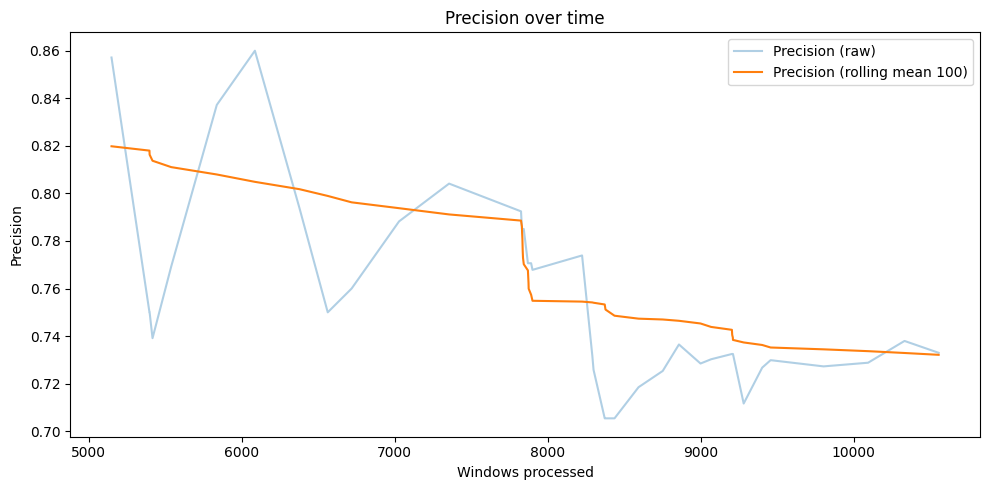

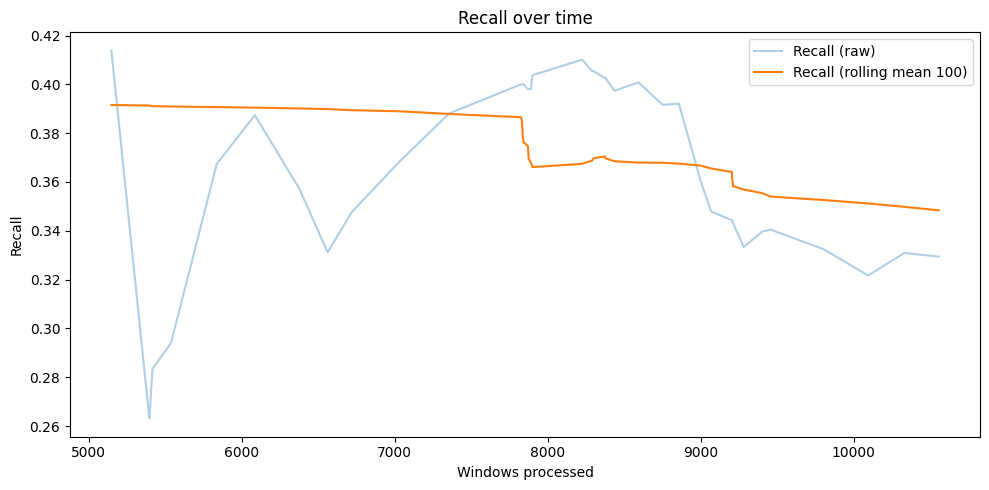

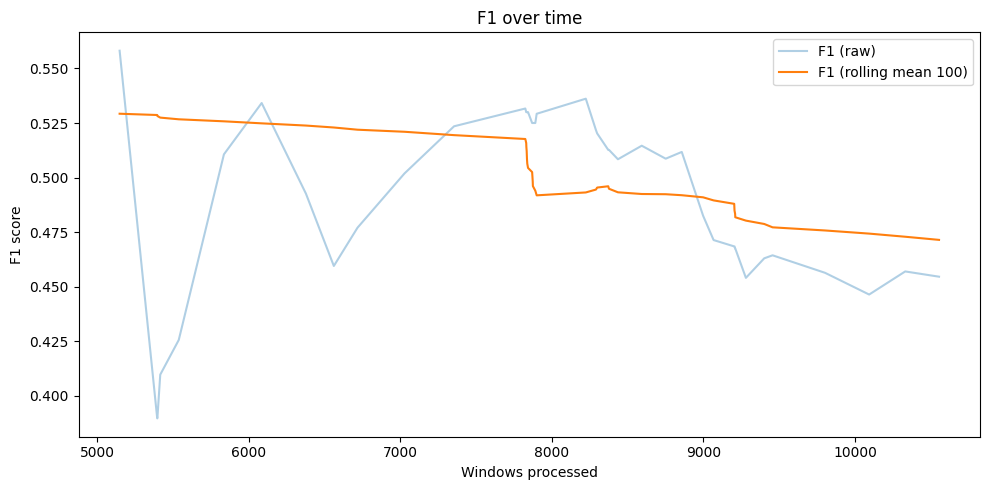

Saved figures to: /home/mih/cs/elfak/diplomski/log-anomaly-analysis/log-anomaly-analysis/data/results/bgl_realtime_streaming/figures


In [8]:
import matplotlib.pyplot as plt

METRICS_DIR = OUT / "metrics"
FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(METRICS_DIR.glob("*.parquet"))
if not files:
    print(f"No metrics files found in {METRICS_DIR}")
else:
    # Load & tidy
    df = pl.concat([pl.read_parquet(f) for f in files], how="vertical", rechunk=True)
    if "WindowsProcessed" in df.columns:
        df = df.unique(subset=["WindowsProcessed"], keep="last").sort(
            "WindowsProcessed"
        )
    # Drop pre-warmup zeros
    df = df.filter(
        (pl.col("Precision") > 0) | (pl.col("Recall") > 0) | (pl.col("F1") > 0)
    )

    wp = df["WindowsProcessed"].to_numpy()
    prec = df["Precision"].to_numpy()
    rec = df["Recall"].to_numpy()
    f1 = df["F1"].to_numpy()

    k = df.get_column("k").to_numpy() if "k" in df.columns else None
    spe_thr = (
        df.get_column("SPE_threshold").to_numpy()
        if "SPE_threshold" in df.columns
        else None
    )
    t2_thr = (
        df.get_column("T2_threshold").to_numpy()
        if "T2_threshold" in df.columns
        else None
    )

    # Always returns SAME length as x (even window sizes too)
    def rolling_mean(x: np.ndarray, w: int = 100) -> np.ndarray:
        if x is None or x.size == 0:
            return x
        w = max(1, min(int(w), x.size))
        if w == 1:
            return x.astype(float)
        kernel = np.ones(w, dtype=float) / w
        left = (w - 1) // 2
        right = (w - 1) - left  # ensures left+right = w-1
        xp = np.pad(x, (left, right), mode="edge")
        y = np.convolve(xp, kernel, mode="valid")
        # y has length len(x); guaranteed
        return y.astype(float)

    SMOOTH = True
    WIN = 100  # any int; even now works

    prec_s = rolling_mean(prec, WIN) if SMOOTH else prec
    rec_s = rolling_mean(rec, WIN) if SMOOTH else rec
    f1_s = rolling_mean(f1, WIN) if SMOOTH else f1

    # --- Precision ---
    plt.figure(figsize=(10, 5))
    plt.plot(wp, prec, alpha=0.35, label="Precision (raw)")
    if SMOOTH:
        plt.plot(wp, prec_s, label=f"Precision (rolling mean {WIN})")
    plt.xlabel("Windows processed")
    plt.ylabel("Precision")
    plt.title("Precision over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "precision.png", dpi=144)
    plt.show()

    # --- Recall ---
    plt.figure(figsize=(10, 5))
    plt.plot(wp, rec, alpha=0.35, label="Recall (raw)")
    if SMOOTH:
        plt.plot(wp, rec_s, label=f"Recall (rolling mean {WIN})")
    plt.xlabel("Windows processed")
    plt.ylabel("Recall")
    plt.title("Recall over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "recall.png", dpi=144)
    plt.show()

    # --- F1 ---
    plt.figure(figsize=(10, 5))
    plt.plot(wp, f1, alpha=0.35, label="F1 (raw)")
    if SMOOTH:
        plt.plot(wp, f1_s, label=f"F1 (rolling mean {WIN})")
    plt.xlabel("Windows processed")
    plt.ylabel("F1 score")
    plt.title("F1 over time")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "f1.png", dpi=144)
    plt.show()

    print("Saved figures to:", FIG_DIR)